# Phase 1: Exploratory Data Analysis
**LendingClub Loan Default Prediction**

Goal: understand the data distribution, class imbalance, key feature relationships, and identify post-origination columns to exclude before modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

DATA_PATH = r'C:\Users\Administrator\Desktop\DataMiningProject\accepted_2007_to_2018Q4.csv'
SAMPLE = 100_000

## 1. Data Loading
We sample 100k rows for EDA which should be sufficient for representative distributions without loading the full 1.68 GB file.

In [3]:
df_raw = pd.read_csv(DATA_PATH, nrows=SAMPLE, low_memory=False)
print(f"Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"\nColumn dtypes:")
print(df_raw.dtypes.value_counts())
df_raw.head(3)

Loaded: 100,000 rows x 151 columns

Column dtypes:
float64    114
object      36
int64        1
Name: count, dtype: int64


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Target Variable
Filter to only `Fully Paid` and `Charged Off` — the two terminal states we can model.

In [4]:
print("All loan_status values in sample:")
print(df_raw['loan_status'].value_counts())

df = df_raw[df_raw['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['target'] = (df['loan_status'] == 'Charged Off').astype(int)

print(f"\nAfter filtering: {len(df):,} rows")
print(f"Default rate: {df['target'].mean():.2%}")

All loan_status values in sample:
loan_status
Fully Paid            70288
Charged Off           17603
Current               11402
Late (31-120 days)      441
In Grace Period         199
Late (16-30 days)        66
Default                   1
Name: count, dtype: int64

After filtering: 87,891 rows
Default rate: 20.03%


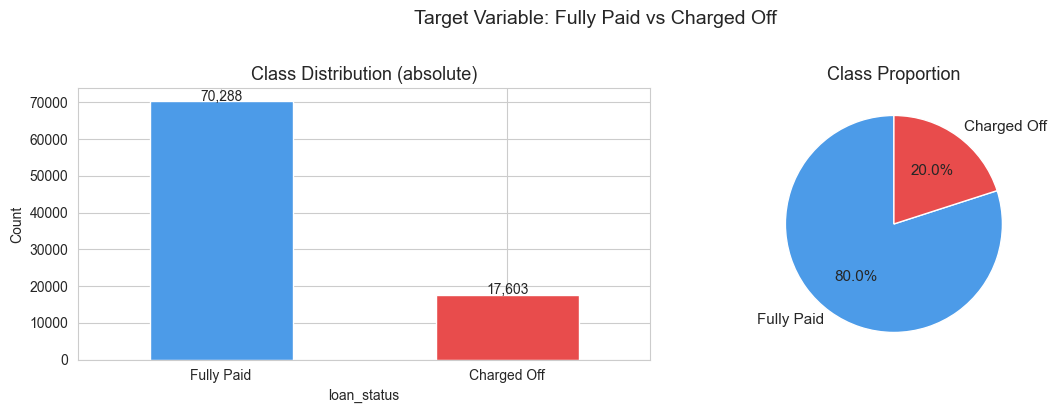

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['loan_status'].value_counts()
colors = ['#4C9BE8', '#E84C4C']

counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Class Distribution (absolute)', fontsize=13)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(counts):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[1].set_ylabel('')
axes[1].set_title('Class Proportion', fontsize=13)

plt.suptitle('Target Variable: Fully Paid vs Charged Off', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 3. Default Rate by Grade & Sub-Grade
LendingClub assigns grades A–G. We check whether the grade system monotonically separates default risk.

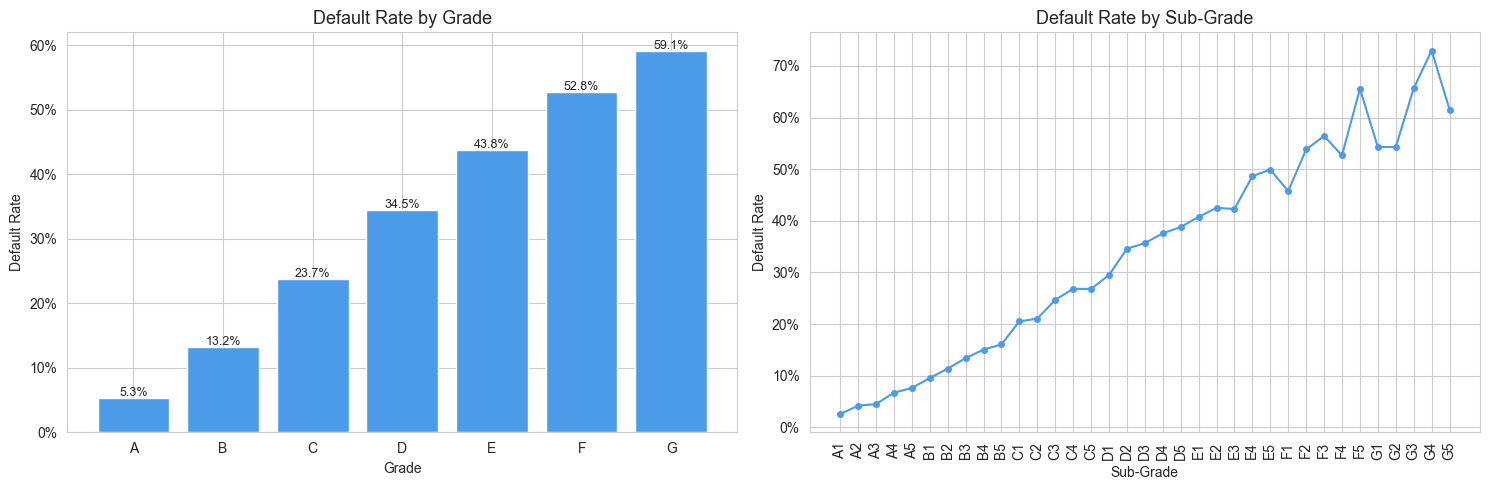

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# By grade
grade_stats = df.groupby('grade')['target'].agg(['mean', 'count']).sort_index()
bars = axes[0].bar(grade_stats.index, grade_stats['mean'], color='#4C9BE8', edgecolor='white')
axes[0].set_title('Default Rate by Grade', fontsize=13)
axes[0].set_ylabel('Default Rate')
axes[0].set_xlabel('Grade')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for bar, (_, row) in zip(bars, grade_stats.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f"{row['mean']:.1%}", ha='center', fontsize=9)

# By sub_grade
sg_stats = df.groupby('sub_grade')['target'].mean()
axes[1].plot(sg_stats.index, sg_stats.values, marker='o', markersize=4,
             color='#4C9BE8', linewidth=1.5)
axes[1].set_title('Default Rate by Sub-Grade', fontsize=13)
axes[1].set_ylabel('Default Rate')
axes[1].set_xlabel('Sub-Grade')
axes[1].tick_params(axis='x', rotation=90)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.show()

## 4. Default Rate by Loan Purpose

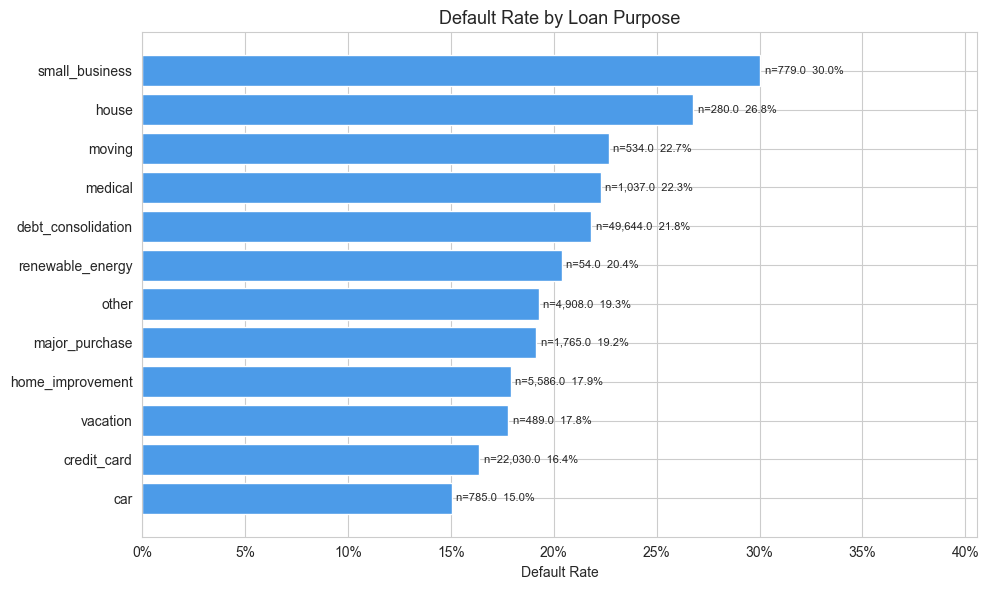

In [7]:
purpose_stats = (df.groupby('purpose')['target']
                 .agg(['mean', 'count'])
                 .sort_values('mean', ascending=True))

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(purpose_stats.index, purpose_stats['mean'],
               color='#4C9BE8', edgecolor='white')

# Add count annotations
for bar, (_, row) in zip(bars, purpose_stats.iterrows()):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"n={row['count']:,}  {row['mean']:.1%}", va='center', fontsize=8)

ax.set_title('Default Rate by Loan Purpose', fontsize=13)
ax.set_xlabel('Default Rate')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_xlim(0, purpose_stats['mean'].max() * 1.35)
plt.tight_layout()
plt.show()

## 5. Default Rate by Term & Home Ownership

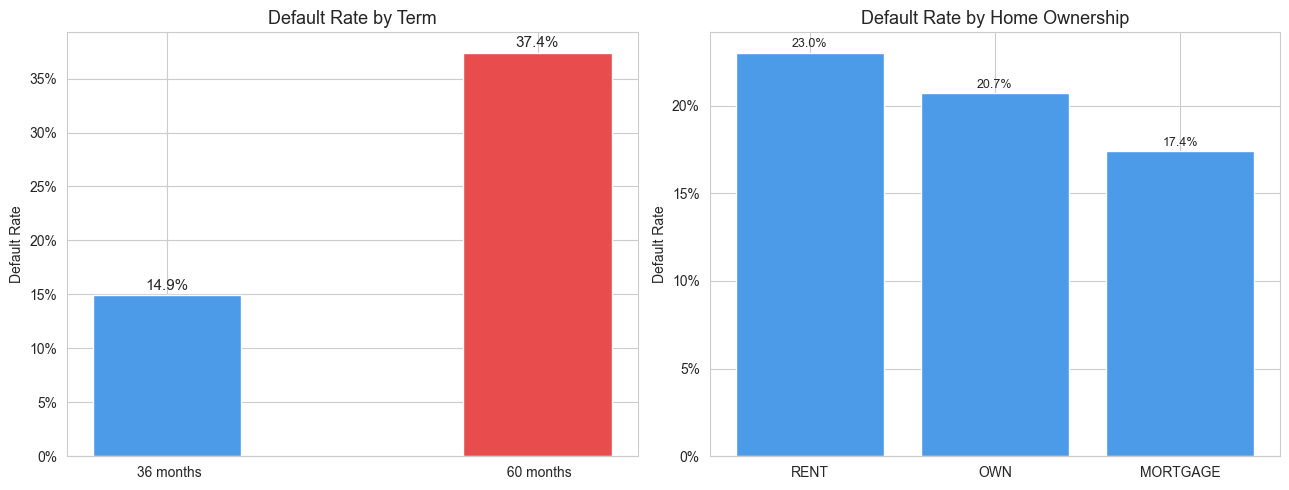

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Term
term_stats = df.groupby('term')['target'].mean()
axes[0].bar(term_stats.index, term_stats.values, color=['#4C9BE8', '#E84C4C'], edgecolor='white', width=0.4)
axes[0].set_title('Default Rate by Term', fontsize=13)
axes[0].set_ylabel('Default Rate')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for i, v in enumerate(term_stats.values):
    axes[0].text(i, v + 0.005, f'{v:.1%}', ha='center', fontsize=11)
axes[0].set_xticks(range(len(term_stats)))
axes[0].set_xticklabels(term_stats.index)

# Home ownership
ho_stats = (df.groupby('home_ownership')['target']
             .agg(['mean', 'count'])
             .query('count > 50')
             .sort_values('mean', ascending=False))
axes[1].bar(ho_stats.index, ho_stats['mean'], color='#4C9BE8', edgecolor='white')
axes[1].set_title('Default Rate by Home Ownership', fontsize=13)
axes[1].set_ylabel('Default Rate')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for i, v in enumerate(ho_stats['mean']):
    axes[1].text(i, v + 0.003, f'{v:.1%}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Numerical Feature Distributions by Class
Overlay distributions for Fully Paid vs Charged Off to see separation.

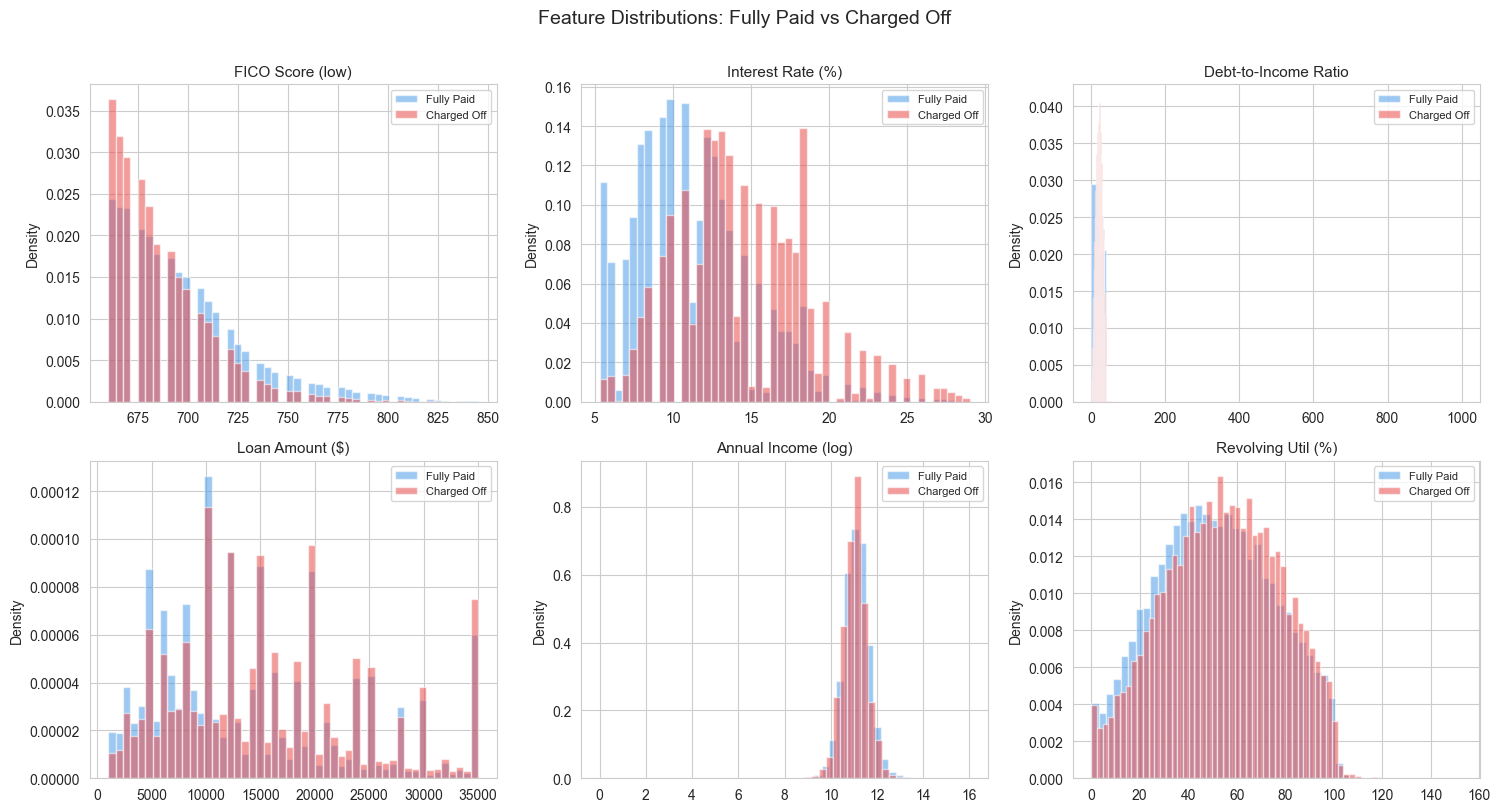

In [9]:
num_cols = [
    ('fico_range_low',  'FICO Score (low)',   False),
    ('int_rate',        'Interest Rate (%)',   False),
    ('dti',             'Debt-to-Income Ratio', False),
    ('loan_amnt',       'Loan Amount ($)',      False),
    ('annual_inc',      'Annual Income (log)',  True),
    ('revol_util',      'Revolving Util (%)',   False),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, label, log_transform) in enumerate(num_cols):
    subset = df[['loan_status', col]].dropna()
    for status, color in [('Fully Paid', '#4C9BE8'), ('Charged Off', '#E84C4C')]:
        vals = subset[subset['loan_status'] == status][col]
        if log_transform:
            vals = np.log1p(vals)
        axes[i].hist(vals, bins=50, alpha=0.55, color=color, label=status, density=True)
    axes[i].set_title(label, fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('Density')

plt.suptitle('Feature Distributions: Fully Paid vs Charged Off', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Default Rate by Employment Length

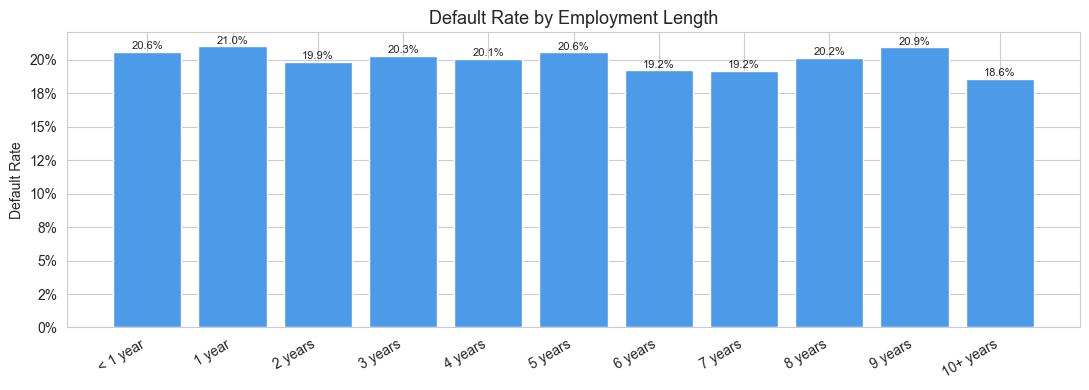

In [10]:
# Fix ordering of emp_length
emp_order = ['< 1 year', '1 year', '2 years', '3 years', '4 years',
             '5 years', '6 years', '7 years', '8 years', '9 years', '10+ years']

emp_stats = (df.groupby('emp_length')['target']
              .agg(['mean', 'count'])
              .reindex([e for e in emp_order if e in df['emp_length'].unique()]))

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(len(emp_stats)), emp_stats['mean'], color='#4C9BE8', edgecolor='white')
ax.set_xticks(range(len(emp_stats)))
ax.set_xticklabels(emp_stats.index, rotation=30, ha='right')
ax.set_title('Default Rate by Employment Length', fontsize=13)
ax.set_ylabel('Default Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
for i, v in enumerate(emp_stats['mean']):
    ax.text(i, v + 0.002, f'{v:.1%}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 8. Missing Values Analysis

Columns with missing values: 73 / 152
Columns with >50% missing: 57
Columns with >90% missing: 39


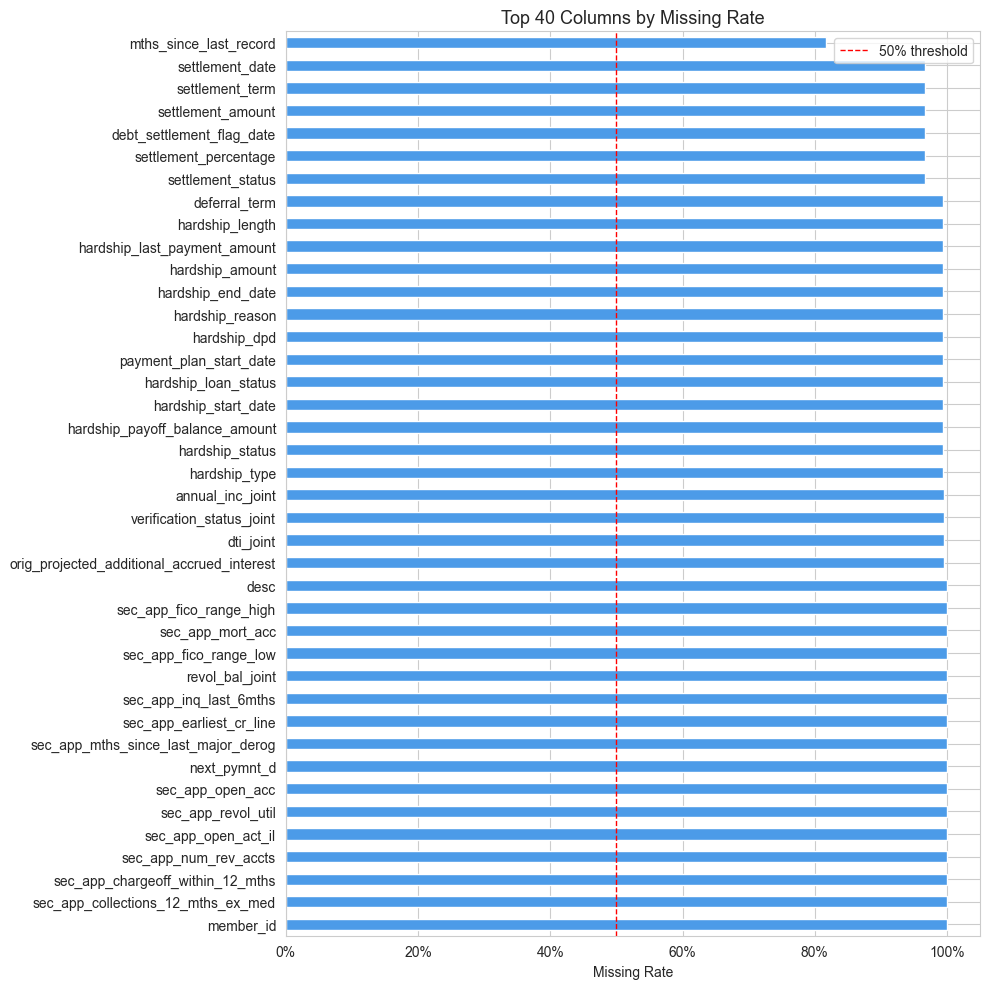

In [11]:
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]

print(f"Columns with missing values: {len(missing)} / {df.shape[1]}")
print(f"Columns with >50% missing: {(missing > 0.5).sum()}")
print(f"Columns with >90% missing: {(missing > 0.9).sum()}")

# Plot top 40
top_missing = missing.head(40)
fig, ax = plt.subplots(figsize=(10, 10))
top_missing.plot(kind='barh', ax=ax, color='#4C9BE8')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax.set_title('Top 40 Columns by Missing Rate', fontsize=13)
ax.set_xlabel('Missing Rate')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
plt.tight_layout()
plt.show()

## 9. Correlation Heatmap
Focus on key numeric features and their correlation with the target.

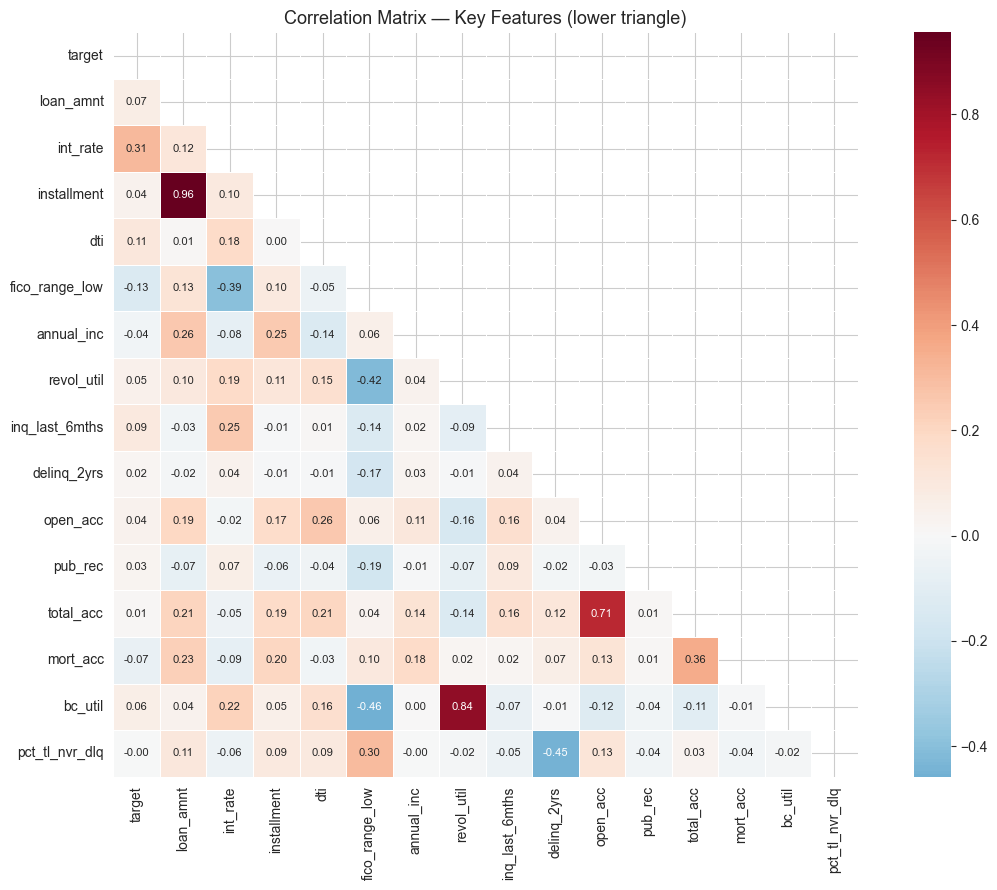


Top correlations with target (default):
int_rate          0.307802
fico_range_low   -0.134629
dti               0.106455
inq_last_6mths    0.094982
loan_amnt         0.072314
mort_acc         -0.066607
bc_util           0.061898
revol_util        0.049528
open_acc          0.043924
installment       0.040269
annual_inc       -0.037545
pub_rec           0.025606
delinq_2yrs       0.018336
total_acc         0.014975
pct_tl_nvr_dlq   -0.004755


In [12]:
key_cols = [
    'target', 'loan_amnt', 'int_rate', 'installment', 'dti',
    'fico_range_low', 'annual_inc', 'revol_util',
    'inq_last_6mths', 'delinq_2yrs', 'open_acc',
    'pub_rec', 'total_acc', 'mort_acc',
    'bc_util', 'pct_tl_nvr_dlq'
]
# Keep only columns that exist in df
key_cols = [c for c in key_cols if c in df.columns]

corr = df[key_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.4,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation Matrix — Key Features (lower triangle)', fontsize=13)
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)
print("\nTop correlations with target (default):")
print(target_corr.to_string())

## 10. FICO vs Interest Rate (Scatter)
Visualize how grade, FICO, and interest rate relate — and whether charged-off loans cluster.

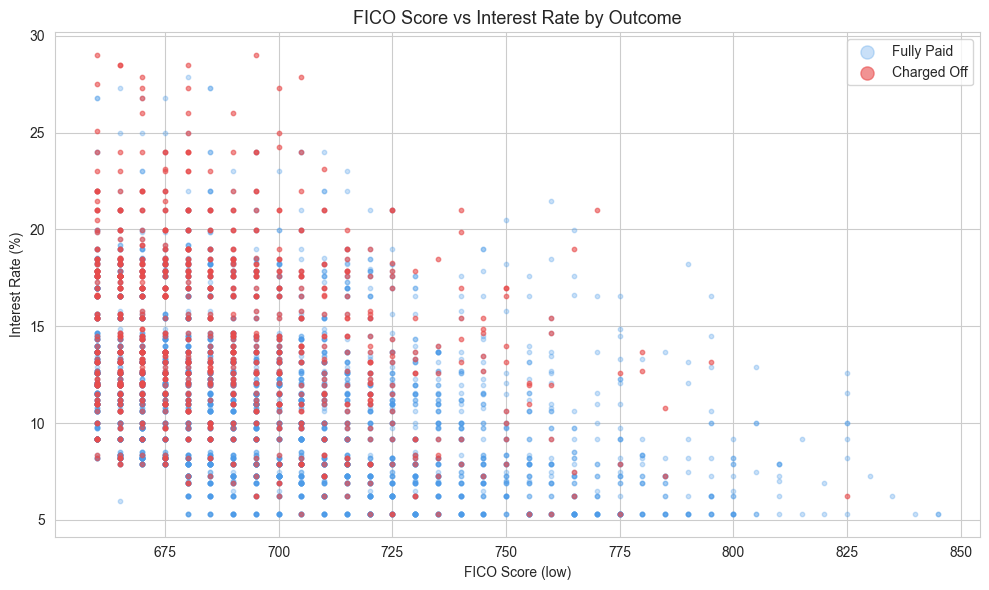

In [13]:
sample_plot = df.sample(min(5000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
for status, color, alpha in [('Fully Paid', '#4C9BE8', 0.3), ('Charged Off', '#E84C4C', 0.6)]:
    sub = sample_plot[sample_plot['loan_status'] == status]
    ax.scatter(sub['fico_range_low'], sub['int_rate'],
               c=color, alpha=alpha, s=10, label=status)

ax.set_xlabel('FICO Score (low)')
ax.set_ylabel('Interest Rate (%)')
ax.set_title('FICO Score vs Interest Rate by Outcome', fontsize=13)
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

## 11. Post-Origination Columns to Exclude
These columns are populated **after** the loan is issued. Including them would cause data leakage.

In [14]:
POST_ORIGINATION_COLS = [
    # Payment outcome columns
    'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee',
    'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d',
    # Post-issuance credit pulls
    'last_credit_pull_d',
    'last_fico_range_high', 'last_fico_range_low',
    # Hardship program (entered after origination)
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status',
    'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    # Debt settlement (post-default)
    'debt_settlement_flag', 'debt_settlement_flag_date',
    'settlement_status', 'settlement_date', 'settlement_amount',
    'settlement_percentage', 'settlement_term',
]

# Check which ones actually exist in our dataset
existing = [c for c in POST_ORIGINATION_COLS if c in df.columns]
print(f"Post-origination columns present in dataset: {len(existing)}")
for c in existing:
    print(f"  {c}")

# Also list columns to DROP for other reasons (IDs, free text, etc.)
DROP_OTHER = ['id', 'member_id', 'url', 'desc', 'title', 'zip_code',
              'funded_amnt', 'funded_amnt_inv',  # near-duplicate of loan_amnt
              'policy_code',  # single value
              'pymnt_plan',   # single value
              ]
print(f"\nOther columns to drop: {DROP_OTHER}")

Post-origination columns present in dataset: 37
  out_prncp
  out_prncp_inv
  total_pymnt
  total_pymnt_inv
  total_rec_prncp
  total_rec_int
  total_rec_late_fee
  recoveries
  collection_recovery_fee
  last_pymnt_d
  last_pymnt_amnt
  next_pymnt_d
  last_credit_pull_d
  last_fico_range_high
  last_fico_range_low
  hardship_flag
  hardship_type
  hardship_reason
  hardship_status
  deferral_term
  hardship_amount
  hardship_start_date
  hardship_end_date
  payment_plan_start_date
  hardship_length
  hardship_dpd
  hardship_loan_status
  orig_projected_additional_accrued_interest
  hardship_payoff_balance_amount
  hardship_last_payment_amount
  debt_settlement_flag
  debt_settlement_flag_date
  settlement_status
  settlement_date
  settlement_amount
  settlement_percentage
  settlement_term

Other columns to drop: ['id', 'member_id', 'url', 'desc', 'title', 'zip_code', 'funded_amnt', 'funded_amnt_inv', 'policy_code', 'pymnt_plan']


## 12. Engineered Features Preview
Quick sanity check that the feature ideas from the proposal are viable.

fico_drop stats:
count    87891.000000
mean        35.053760
std        128.394035
min       -170.000000
25%        -30.000000
50%          5.000000
75%         70.000000
max        825.000000
Name: fico_drop, dtype: float64

loan_to_income stats:
count    87891.000000
mean         0.481356
std         68.605639
min          0.000309
25%          0.123075
50%          0.199983
75%          0.288118
max      20000.000000
Name: loan_to_income, dtype: float64

credit_age_months stats:
count    87891.000000
mean       203.698316
std         93.431743
min         37.500000
25%        139.000000
50%        184.633333
75%        251.633333
max        802.500000
Name: credit_age_months, dtype: float64


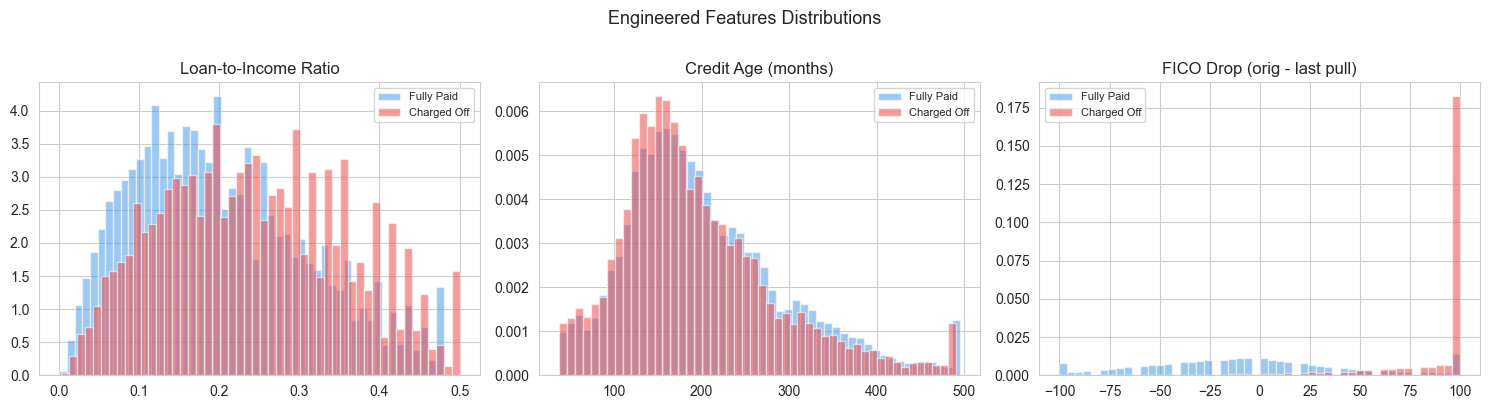

In [15]:
# Loan-to-income ratio
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)

# Credit age in months (earliest_cr_line to issue_d)
df['issue_d_parsed'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
df['earliest_cr_parsed'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
df['credit_age_months'] = ((df['issue_d_parsed'] - df['earliest_cr_parsed'])
                           .dt.days / 30).clip(lower=0)

# FICO drop (original vs last pull) — use only if last_fico available
if 'last_fico_range_low' in df.columns:
    df['fico_drop'] = df['fico_range_low'] - df['last_fico_range_low']
    print("fico_drop stats:")
    print(df['fico_drop'].describe())

print("\nloan_to_income stats:")
print(df['loan_to_income'].describe())

print("\ncredit_age_months stats:")
print(df['credit_age_months'].describe())

# Quick default rate check for engineered features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, label in [
    (axes[0], 'loan_to_income', 'Loan-to-Income Ratio'),
    (axes[1], 'credit_age_months', 'Credit Age (months)'),
]:
    for status, color in [('Fully Paid', '#4C9BE8'), ('Charged Off', '#E84C4C')]:
        vals = df[df['loan_status'] == status][col].dropna()
        ax.hist(vals.clip(upper=vals.quantile(0.99)), bins=50,
                alpha=0.55, color=color, label=status, density=True)
    ax.set_title(label)
    ax.legend(fontsize=8)

if 'fico_drop' in df.columns:
    for status, color in [('Fully Paid', '#4C9BE8'), ('Charged Off', '#E84C4C')]:
        vals = df[df['loan_status'] == status]['fico_drop'].dropna()
        axes[2].hist(vals.clip(-100, 100), bins=50,
                     alpha=0.55, color=color, label=status, density=True)
    axes[2].set_title('FICO Drop (orig - last pull)')
    axes[2].legend(fontsize=8)

plt.suptitle('Engineered Features Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 13. Default Rate by State
Which states show the highest and lowest loan default rates?

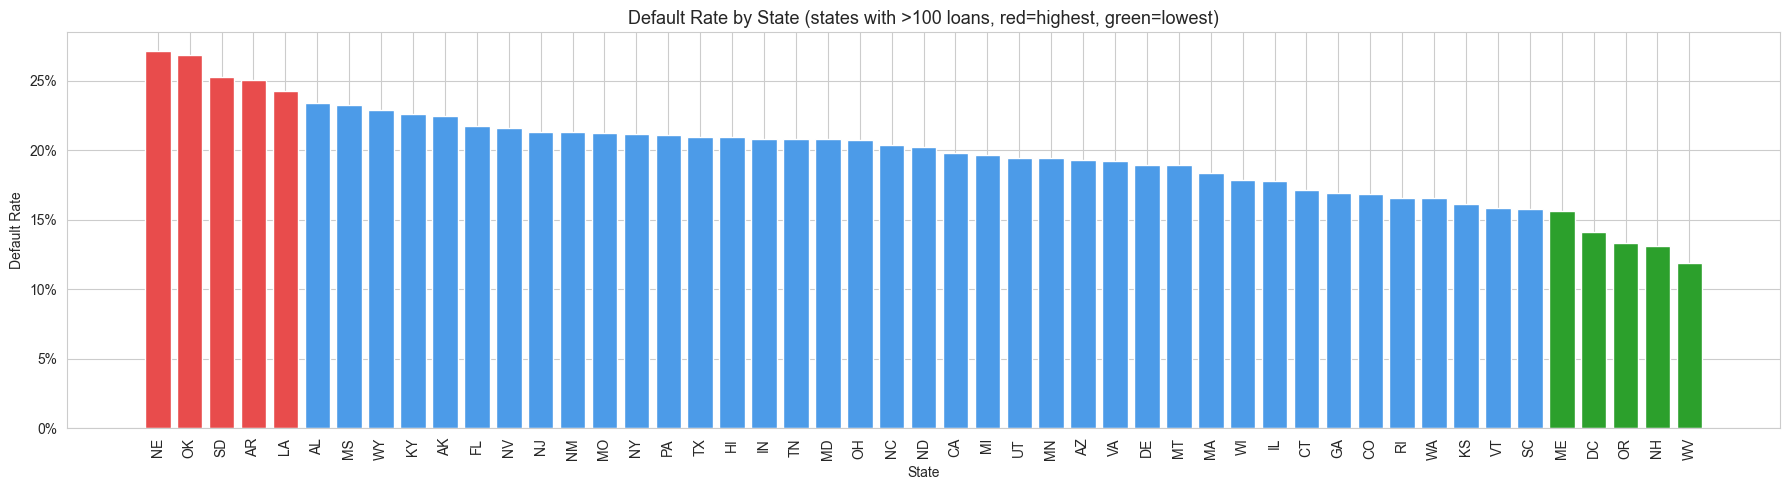

Top 5 highest default states:
            default_rate    n
addr_state                   
NE              0.271429  420
OK              0.268804  811
SD              0.252747  182
AR              0.250370  675
LA              0.242739  964

Top 5 lowest default states:
            default_rate    n
addr_state                   
ME              0.156593  364
DC              0.141509  212
OR              0.133470  974
NH              0.131034  435
WV              0.119205  302


In [16]:
state_stats = (df.groupby('addr_state')['target']
               .agg(['mean', 'count'])
               .query('count > 100')
               .sort_values('mean', ascending=False))

fig, ax = plt.subplots(figsize=(18, 5))
colors_bar = ['#E84C4C' if i < 5 else ('#2CA02C' if i >= len(state_stats)-5 else '#4C9BE8')
              for i in range(len(state_stats))]
ax.bar(state_stats.index, state_stats['mean'], color=colors_bar, edgecolor='white')
ax.set_title('Default Rate by State (states with >100 loans, red=highest, green=lowest)', fontsize=13)
ax.set_ylabel('Default Rate')
ax.set_xlabel('State')
ax.tick_params(axis='x', rotation=90)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

print('Top 5 highest default states:')
print(state_stats.head(5)[['mean','count']].rename(columns={'mean':'default_rate','count':'n'}).to_string())
print()
print('Top 5 lowest default states:')
print(state_stats.tail(5)[['mean','count']].rename(columns={'mean':'default_rate','count':'n'}).to_string())

## 14. Rejected Applications — Exploratory Comparison
Compare key features between rejected and accepted (including defaulted) loans.

Rejected sample: 100,000 rows x 9 columns
Columns: ['Amount Requested', 'Application Date', 'Loan Title', 'Risk_Score', 'Debt-To-Income Ratio', 'Zip Code', 'State', 'Employment Length', 'Policy Code']


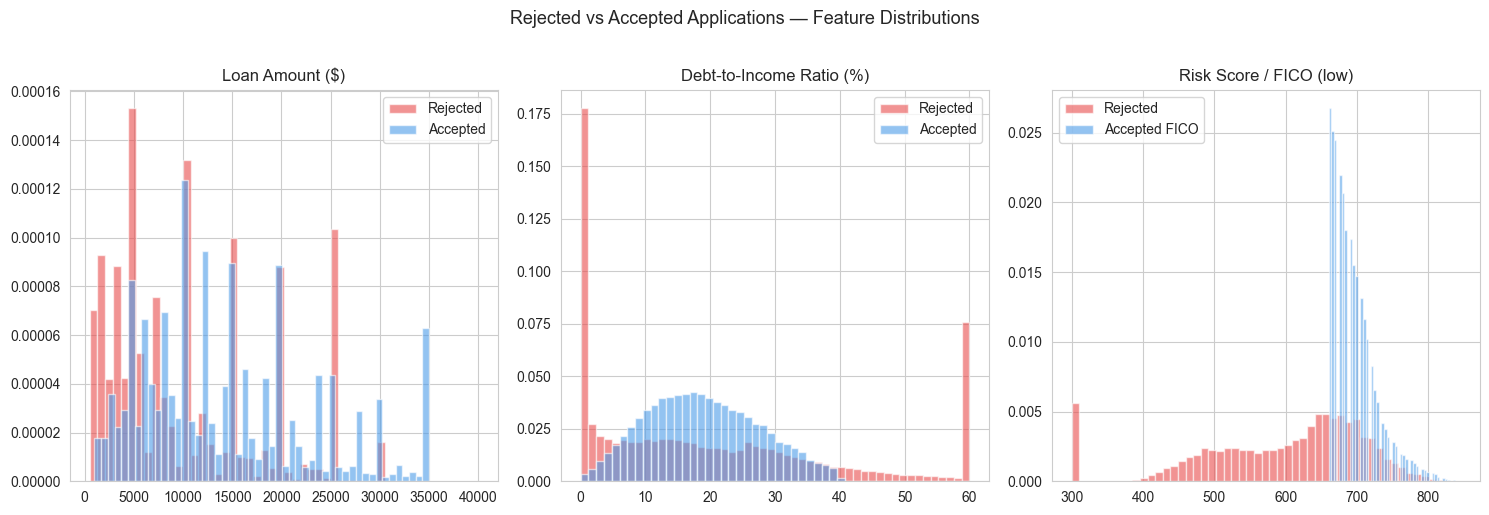


Median loan amount  — Rejected: $8,000  |  Accepted: $12,000
Median DTI          — Rejected: 15.5%  |  Accepted: 18.4%
Median Risk Score   — Rejected: 627  |  Accepted FICO low: 685


In [17]:
REJ_PATH = r'C:\Users\Administrator\Desktop\DataMiningProject\rejected_2007_to_2018Q4.csv'
df_rej = pd.read_csv(REJ_PATH, nrows=100_000, low_memory=False)
print(f'Rejected sample: {df_rej.shape[0]:,} rows x {df_rej.shape[1]} columns')
print(f'Columns: {list(df_rej.columns)}')

df_rej['dti_val'] = pd.to_numeric(df_rej['Debt-To-Income Ratio'].astype(str).str.rstrip('%'), errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df_rej['Amount Requested'].dropna().clip(upper=40000), bins=50, alpha=0.6, color='#E84C4C', label='Rejected', density=True)
axes[0].hist(df['loan_amnt'].clip(upper=40000), bins=50, alpha=0.6, color='#4C9BE8', label='Accepted', density=True)
axes[0].set_title('Loan Amount ($)')
axes[0].legend()

axes[1].hist(df_rej['dti_val'].dropna().clip(0, 60), bins=50, alpha=0.6, color='#E84C4C', label='Rejected', density=True)
axes[1].hist(df['dti'].dropna().clip(0, 60), bins=50, alpha=0.6, color='#4C9BE8', label='Accepted', density=True)
axes[1].set_title('Debt-to-Income Ratio (%)')
axes[1].legend()

axes[2].hist(df_rej['Risk_Score'].dropna().clip(300, 850), bins=50, alpha=0.6, color='#E84C4C', label='Rejected', density=True)
axes[2].hist(df['fico_range_low'].dropna().clip(300, 850), bins=50, alpha=0.6, color='#4C9BE8', label='Accepted FICO', density=True)
axes[2].set_title('Risk Score / FICO (low)')
axes[2].legend()

plt.suptitle('Rejected vs Accepted Applications — Feature Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nMedian loan amount  — Rejected: ${df_rej["Amount Requested"].median():,.0f}  |  Accepted: ${df["loan_amnt"].median():,.0f}')
print(f'Median DTI          — Rejected: {df_rej["dti_val"].median():.1f}%  |  Accepted: {df["dti"].median():.1f}%')
print(f'Median Risk Score   — Rejected: {df_rej["Risk_Score"].median():.0f}  |  Accepted FICO low: {df["fico_range_low"].median():.0f}')

## Key Observations

1. **Class imbalance**: ~20% default rate — confirms need for SMOTE /  adjustment.
2. **Grade monotonicity**: Grade A→G shows a clean increasing default rate — grade is a strong ordinal signal.
3. **Interest rate**: Strongest single predictor (r = +0.31). Charged Off loans cluster at higher int_rate.
4. **FICO**: Second-strongest correlate (r = −0.13). Lower FICO scores associate with defaults.
5. **DTI**: Positive correlation with default (r = +0.11) — higher leverage borrowers default more.
6. **Missing values**: 73/157 columns have missing data; 57 have >50% missing (dropped in preprocessing); 39 have >90% missing.
7. **Post-origination leakage**: 37 columns excluded (total_pymnt, out_prncp, recoveries, etc.) — populated after loan outcome is known.
8. **Loan purpose**: Small-business and moving loans show higher default rates; car/wedding/major-purchase lower.
9. **Term**: 60-month loans default significantly more than 36-month (~26% vs ~16%).
10. **State variation**: Notable geographic dispersion in default rates; a few states stand out at the extremes.
11. **Rejected vs Accepted**: Rejected applicants have higher DTI and lower risk scores than accepted borrowers — confirms LendingClub's screening selects lower-risk profiles.
12. **Engineered features**: loan_to_income and credit_age_months show class separation; fico_drop is a useful additional signal.